In [16]:
import sys
sys.path.append("..")
from pathlib import Path
import pandas as pd
import importlib

import src.ingestion, src.preprocessing, src.features, src.modelling
importlib.reload(src.ingestion)
importlib.reload(src.preprocessing)
importlib.reload(src.features)
importlib.reload(src.modelling)
import pickle
import json
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [17]:

from src.ingestion import build_dataframe, load_labels
from src.preprocessing import add_clean_text_column
from src.features import add_engineered_features
from src.modelling import compare_text_representations, compare_models, build_calibrated_pipeline


In [18]:

BASE_DIR = Path(r"C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier")
TRAIN_DIR, TEST_DIR, LABELS_PATH = BASE_DIR / "train", BASE_DIR / "test", BASE_DIR / "train_labels.csv"

train_df = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)
labels_df = load_labels(LABELS_PATH)

train_labeled = train_df.merge(labels_df, left_on="source_filename", right_on="filename", how="left")
train_labeled = add_clean_text_column(train_labeled)
train_labeled = add_engineered_features(train_labeled)
test_df = add_clean_text_column(test_df)
test_df = add_engineered_features(test_df)

y = train_labeled["true_category"]
print("Ready:", train_labeled.shape)

Ready: (44, 19)


In [19]:
representation_results = compare_text_representations(train_labeled, y)
for name, (mean_f1, std_f1) in representation_results.items():
    print(f"{name}: F1-macro = {mean_f1:.3f} (+/- {std_f1:.3f})")

fused: F1-macro = 0.786 (+/- 0.190)
separated: F1-macro = 0.894 (+/- 0.107)


In [20]:
# # À ajuster selon le gagnant de la Cellule 2 : "clean_text" ou ("subject", "message")
# best_representation = "clean_text"  # ou ("subject", "message")

# X = (train_labeled[["clean_text"] + src.modelling.STRUCTURED_BOOL_COLS + src.modelling.STRUCTURED_NUM_COLS]
#      if best_representation == "clean_text"
#      else train_labeled[["subject", "message"] + src.modelling.STRUCTURED_BOOL_COLS + src.modelling.STRUCTURED_NUM_COLS])

# model_results = compare_models(X, y, best_representation)
# for name, (mean_f1, std_f1) in model_results.items():
#     print(f"{name}: F1-macro = {mean_f1:.3f} (+/- {std_f1:.3f})")



best_representation = ("subject", "message")

X = train_labeled[["subject", "message"] + src.modelling.STRUCTURED_BOOL_COLS + src.modelling.STRUCTURED_NUM_COLS]

model_results = compare_models(X, y, best_representation)
for name, (mean_f1, std_f1) in model_results.items():
    print(f"{name}: F1-macro = {mean_f1:.3f} (+/- {std_f1:.3f})")

logistic_regression: F1-macro = 0.894 (+/- 0.107)
linear_svm: F1-macro = 0.947 (+/- 0.076)
naive_bayes: F1-macro = 0.655 (+/- 0.070)


In [21]:
# À ajuster selon le gagnant de la Cellule 2 : "clean_text" ou ("subject", "message")
best_representation = "clean_text"  # ou ("subject", "message")

X = (train_labeled[["clean_text"] + src.modelling.STRUCTURED_BOOL_COLS + src.modelling.STRUCTURED_NUM_COLS]
     if best_representation == "clean_text"
     else train_labeled[["subject", "message"] + src.modelling.STRUCTURED_BOOL_COLS + src.modelling.STRUCTURED_NUM_COLS])

model_results = compare_models(X, y, best_representation)
for name, (mean_f1, std_f1) in model_results.items():
    print(f"{name}: F1-macro = {mean_f1:.3f} (+/- {std_f1:.3f})")

logistic_regression: F1-macro = 0.786 (+/- 0.190)
linear_svm: F1-macro = 0.926 (+/- 0.073)
naive_bayes: F1-macro = 0.638 (+/- 0.076)


In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from src.modelling import build_text_pipeline, STRUCTURED_BOOL_COLS, STRUCTURED_NUM_COLS

# Adjust "clean_text" vs ("subject", "message") based on your A/B comparison winner
X = train_labeled[["clean_text"] + STRUCTURED_BOOL_COLS + STRUCTURED_NUM_COLS]
y = train_labeled["true_category"]

pipeline = build_text_pipeline("clean_text", STRUCTURED_BOOL_COLS, STRUCTURED_NUM_COLS,
                                LogisticRegression(max_iter=1000, class_weight="balanced"))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(pipeline, X, y, cv=skf)
y_proba = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")

print("Out-of-sample predictions obtained for all", len(y_pred), "training examples.")

Out-of-sample predictions obtained for all 44 training examples.


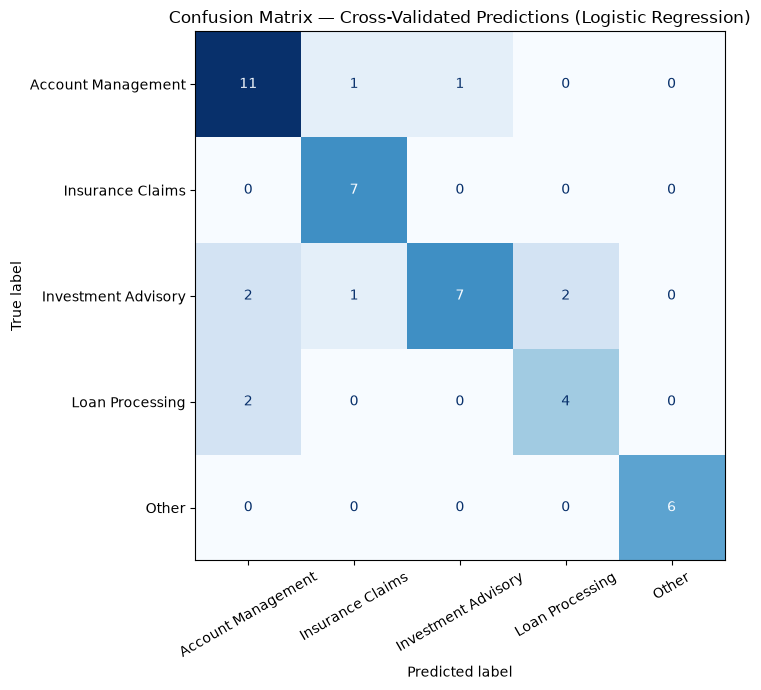

                     precision    recall  f1-score   support

 Account Management       0.73      0.85      0.79        13
   Insurance Claims       0.78      1.00      0.88         7
Investment Advisory       0.88      0.58      0.70        12
    Loan Processing       0.67      0.67      0.67         6
              Other       1.00      1.00      1.00         6

           accuracy                           0.80        44
          macro avg       0.81      0.82      0.81        44
       weighted avg       0.81      0.80      0.79        44



In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

labels_order = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30, colorbar=False)
ax.set_title("Confusion Matrix — Cross-Validated Predictions (Logistic Regression)")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred, labels=labels_order))

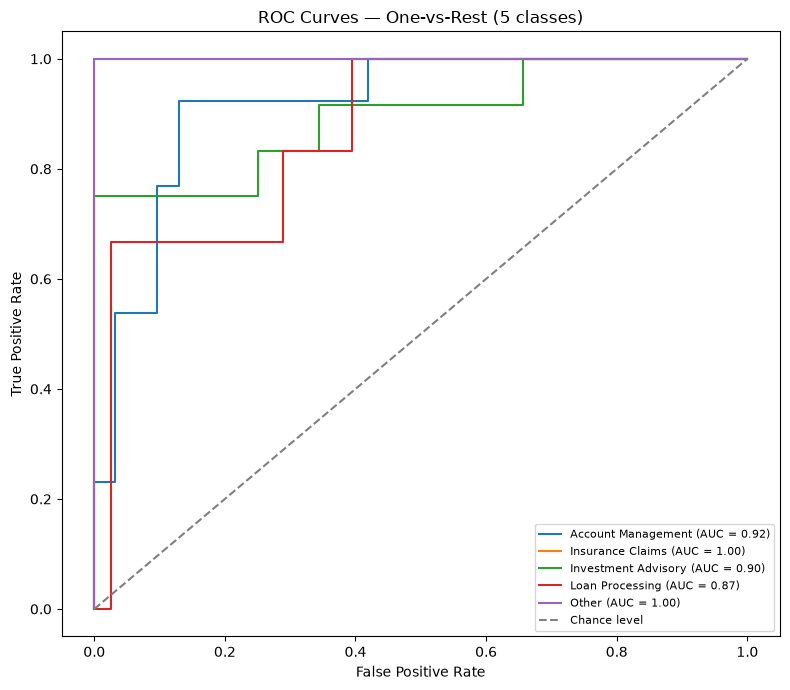

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

pipeline.fit(X, y)  # needed to access pipeline.classes_ in the right order
y_bin = label_binarize(y, classes=pipeline.classes_)
n_classes = y_bin.shape[1]
class_names = pipeline.classes_

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance level")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest (5 classes)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

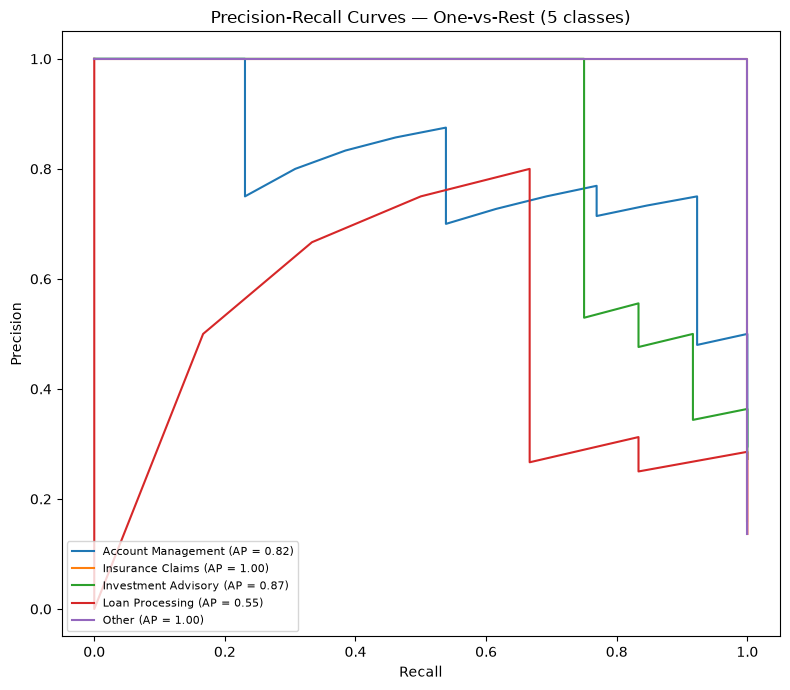

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, label=f"{class_names[i]} (AP = {ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — One-vs-Rest (5 classes)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

In [26]:
from src.modelling import train_and_save_best_model

MODELS_DIR = BASE_DIR / "outputs" / "models"
best_pipeline, metadata = train_and_save_best_model(train_labeled, y, MODELS_DIR)

print(f"Best model saved: {metadata['model_type']} with {metadata['text_representation']} text")
print(f"F1-macro: {metadata['f1_macro_cv_mean']:.3f} (+/- {metadata['f1_macro_cv_std']:.3f})")

Best model saved: LinearSVC with separated text
F1-macro: 0.947 (+/- 0.076)


In [27]:


# MODELS_DIR = Path("models")
# MODELS_DIR.mkdir(exist_ok=True)

# # BEST MODEL: LinearSVC avec ("subject", "message")
# best_representation = ("subject", "message")
# X_best = train_labeled[["subject", "message"] + STRUCTURED_BOOL_COLS + STRUCTURED_NUM_COLS]

# best_clf = LinearSVC(class_weight="balanced", random_state=42)
# best_pipeline = build_text_pipeline(
#     best_representation, STRUCTURED_BOOL_COLS, STRUCTURED_NUM_COLS, best_clf
# )


In [28]:

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(best_pipeline, X_best, y, cv=skf, scoring='f1_macro')

# best_pipeline.fit(X_best, y)


# with open(MODELS_DIR / "best_model_raw.pkl", "wb") as f:
#     pickle.dump(best_pipeline, f)


In [29]:


# metadata = {
#     "model_type": "LinearSVC",
#     "text_representation": "separated",
#     "text_columns": ["subject", "message"],
#     "structured_features": STRUCTURED_BOOL_COLS + STRUCTURED_NUM_COLS,
#     "classes": sorted(y.unique()),
#     "n_samples": len(y),
#     "f1_macro_cv_mean": float(cv_scores.mean()),
#     "f1_macro_cv_std": float(cv_scores.std()),
#     "cv_scores_all": cv_scores.tolist(),
#     "notes": "Best performer from 02_modelling comparison. Use for calibration."
# }
# with open(MODELS_DIR / "metadata.json", "w") as f:
#     json.dump(metadata, f, indent=2)



In [30]:

# print(f"Best model saved: {metadata['model_type']} with {metadata['text_representation']} text")
# print(f"F1-macro: {metadata['f1_macro_cv_mean']:.3f} (+/- {metadata['f1_macro_cv_std']:.3f})")
# print(f"CV scores per fold: {[f'{s:.3f}' for s in metadata['cv_scores_all']]}")
# print(f"Saved to models/best_model_raw.pkl")